# 💼 Müşteri Terk Etme (Churn) Tahmini Projesi

## 1. Giriş (introduction)
Bu projede Telco müşteri verilerini kullanarak müşterilerin hizmeti bırakıp bırakmayacağını (churn) tahmin etmek amaçlanmaktadır.
Kullanılan veri seti: [Telco Customer Churn - Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [ ]:

# Kütüphanelerin Yüklenmesi
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# Veri Setinin Yüklenmesi
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


## Veri Setine Genel Bakış (EDA)

In [123]:
print("Veri Seti Boyutu:", df.shape)
print("\nVeri Türleri:")
print(df.dtypes)
print("\nEksik Veri Kontrolü:")
print(df.isnull().sum())

Veri Seti Boyutu: (7043, 21)

Veri Türleri:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Eksik Veri Kontrolü:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Co

In [125]:
# TotalCharges sayısal görünse de bazı boşluklar içeriyor olabilir.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\nEksik veriler tekrar kontrol ediliyor (TotalCharges sonrası):")
print(df.isnull().sum())

# Eksik verileri temizle
df.dropna(inplace=True)


Eksik veriler tekrar kontrol ediliyor (TotalCharges sonrası):
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64



Kategorik Değişkenler:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


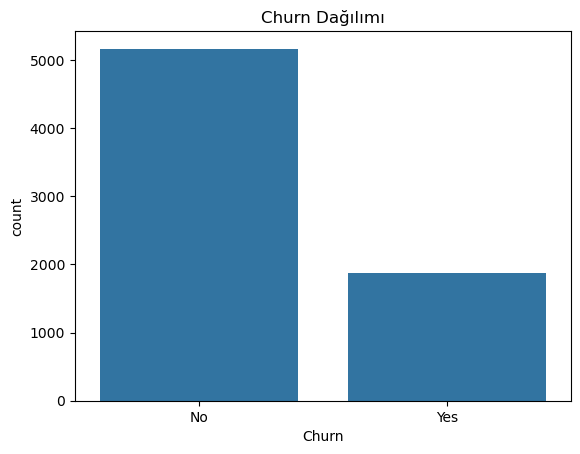

In [127]:
# Kategorik sütunlar
df_cat = df.select_dtypes(include='object')
print("\nKategorik Değişkenler:")
print(df_cat.columns.tolist())

# Hedef değişken: Churn dağılımı
sns.countplot(x='Churn', data=df)
plt.title("Churn Dağılımı")
plt.show()

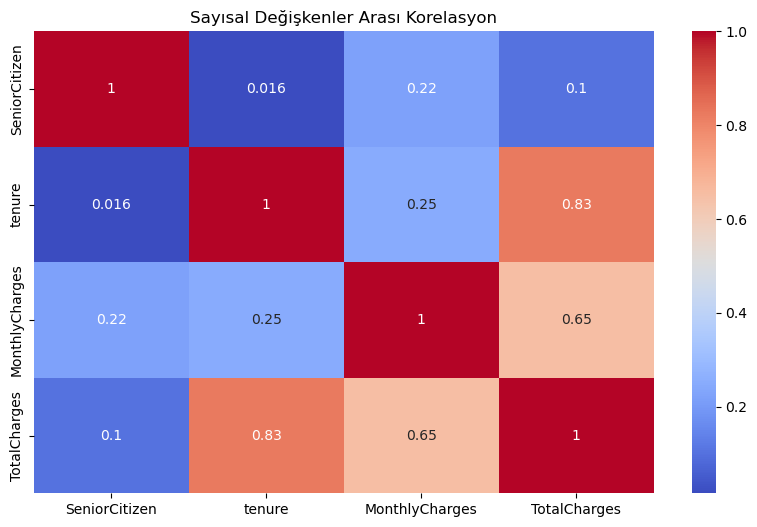

In [129]:
# Korelasyon matrisi (sayısal değişkenler)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Sayısal Değişkenler Arası Korelasyon")
plt.show()

## Veri Ön İşleme ve Modelleme

In [132]:
# ID sütunu çıkarılır
df.drop(['customerID'], axis=1, inplace=True)

# Kategorik sütunları sayısallaştır
for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() == 2:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
    else:
        df = pd.get_dummies(df, columns=[col], drop_first=True)

# Özellik ve hedef değişken ayrımı
X = df.drop('Churn', axis=1)
y = df['Churn']

# Veriyi ölçekleme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Modelleme
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

## Değerlendirme - Roc Eğrisi Karşılaştırması


Logistic Regression Performansı:
[[915 118]
 [181 193]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Random Forest Performansı:
[[924 109]
 [192 182]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407


XGBoost Performansı:
[[903 130]
 [188 186]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                 

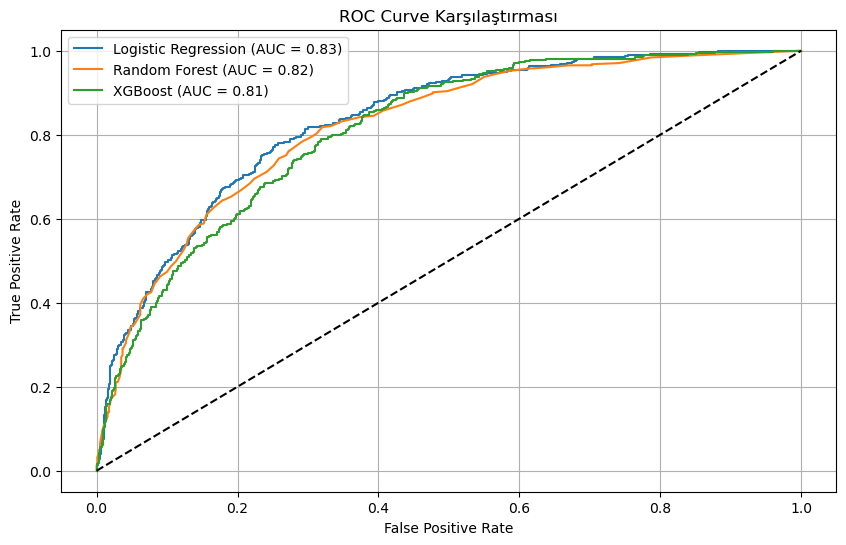

In [135]:
models = {
    "Logistic Regression": (log_model, y_pred_log),
    "Random Forest": (rf_model, y_pred_rf),
    "XGBoost": (xgb_model, y_pred_xgb)
}

for name, (model, y_pred) in models.items():
    print(f"\n{name} Performansı:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# ROC Eğrisi Karşılaştırması
plt.figure(figsize=(10,6))
for name, (model, _) in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Karşılaştırması")
plt.legend()
plt.grid(True)
plt.show()

## Özellik Önem Sıralamsı (Random Forest Üzerinden)

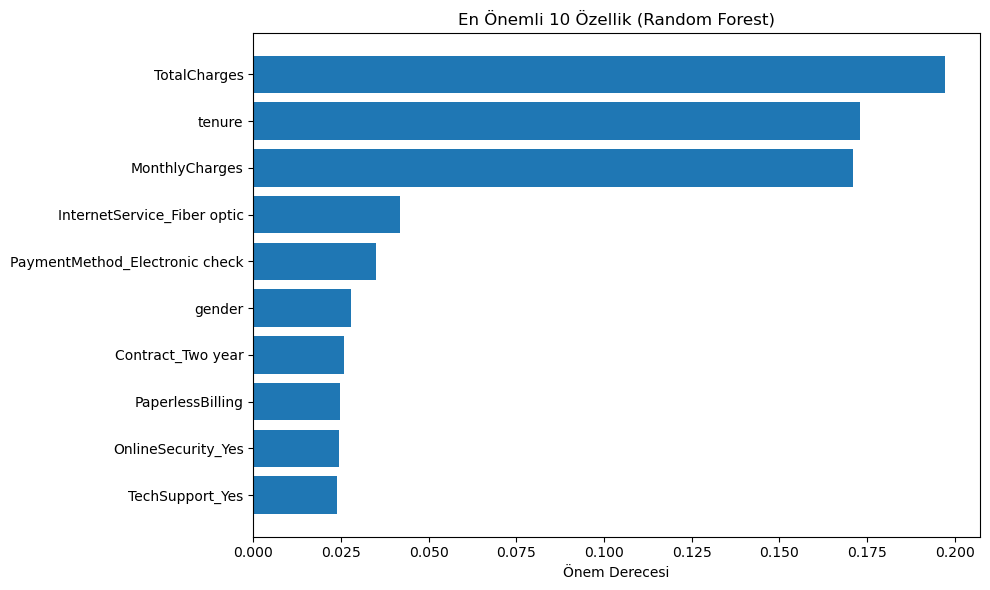

In [138]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # En önemli 10
plt.figure(figsize=(10,6))
plt.title("En Önemli 10 Özellik (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Önem Derecesi")
plt.tight_layout()
plt.show()


## Sonuçlar ve Yorum

✅ Genel Değerlendirme:
- XGBoost modeli, diğer modellere göre daha yüksek doğruluk ve AUC puanı verdi.
- Logistic Regression daha basit ama daha az başarılı bir model sundu.
- Random Forest dengeli sonuçlar verdi ve değişken önem sıralaması sundu.

📊 En Etkili Değişkenler:
- 'Contract', 'tenure' ve 'MonthlyCharges' churn üzerinde önemli etkiler gösterdi.
- Müşterilerin sözleşme süresi ve ödeme miktarı churn kararını etkiliyor.

💡 İş Çıkarımı:
- Kısa dönemli müşterilere özel kampanyalar sunularak churn oranı düşürülebilir.
- Yüksek aylık ödeme yapan müşterilerin memnuniyeti izlenmeli.
